Leonardo Santos Souza RGM: 11241103968
Luis Henrique dos Reis Costa  RGM: 11241102421


In [1]:
import pandas as pd
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/anandambastha/titanic/train (1).csv


In [2]:
df = pd.read_csv('/kaggle/input/datasets/anandambastha/titanic/train (1).csv')

**Nos Blocos abaixo estamos realizando avaliações do Banco**

**Mostra as primeiras linhas**

In [3]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


**Tipos de colunas e quantos valores existem**

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


**Valores que estão faltando**

In [5]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

**Quantidade de linhas e colunas**

In [6]:
df.shape

(891, 12)

**Estatísticas das colunas numéricas**

In [7]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


**TRATAMENTO DA COLUNA AGE** -Após a analise feita estamos realizando uma média da idade dos passageiros para substituir as idades ausentes

In [8]:
# Tratamento da coluna Age
# Os valores ausentes foram substituídos pela mediana das idades.
df['Age'] = df['Age'].fillna(df['Age'].median())

**TRATAMENTO DA COLUNA EMBARKED** - Tratamento esse que foi alterado valores nulos para números com o valor categórico mais frequente..

In [9]:
# Tratamento da coluna Embarked
# Os valores ausentes foram substituídos pela categoria mais frequente.

df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

A coluna Cabin foi excluida pela quantidade grande de dados ausentes.

In [10]:
df = df.drop(columns=['Cabin'])

In [11]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

Realizando o Encoding transformando suas categorias em colunas númericas.

In [12]:
df = pd.get_dummies(df, columns=['Sex', 'Embarked'], drop_first=True)

In [13]:
df.head()

,PassengerId,Survived,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,Sex_male,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",22.0,1,0,A/5 21171,7.2500,True,False,True
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,1,0,PC 17599,71.2833,False,False,False
2,3,1,3,"Heikkinen, Miss. Laina",26.0,0,0,STON/O2. 3101282,7.9250,False,False,True
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,1,0,113803,53.1000,False,False,True
4,5,0,3,"Allen, Mr. William Henry",35.0,0,0,373450,8.0500,True,False,True


Excluindo colunas que não seriam utilizadas por não serem do tratamento do modelo utilizado.

In [14]:
df = df.drop(columns=['PassengerId', 'Name', 'Ticket'])

In [15]:
df.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,0,3,22.0,1,0,7.2500,True,False,True
1,1,1,38.0,1,0,71.2833,False,False,False
2,1,3,26.0,0,0,7.9250,False,False,True
3,1,1,35.0,1,0,53.1000,False,False,True
4,0,3,35.0,0,0,8.0500,True,False,True


Conversão dos valores boleanos para números inteiros.

In [16]:
df = df.astype(int)

In [17]:
df.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,0,3,22,1,0,7,1,0,1
1,1,1,38,1,0,71,0,0,0
2,1,3,26,0,0,7,0,0,1
3,1,1,35,1,0,53,0,0,1
4,0,3,35,0,0,8,1,0,1


Conversão dos valores pagos da passagem para o tipo float.

In [18]:
df['Fare'] = df['Fare'].astype(float)

In [19]:
df.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,0,3,22,1,0,7.0,1,0,1
1,1,1,38,1,0,71.0,0,0,0
2,1,3,26,0,0,7.0,0,0,1
3,1,1,35,1,0,53.0,0,0,1
4,0,3,35,0,0,8.0,1,0,1


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Survived    891 non-null    int64  
 1   Pclass      891 non-null    int64  
 2   Age         891 non-null    int64  
 3   SibSp       891 non-null    int64  
 4   Parch       891 non-null    int64  
 5   Fare        891 non-null    float64
 6   Sex_male    891 non-null    int64  
 7   Embarked_Q  891 non-null    int64  
 8   Embarked_S  891 non-null    int64  
dtypes: float64(1), int64(8)
memory usage: 62.8 KB


In [21]:
df.isnull().sum()

Survived      0
Pclass        0
Age           0
SibSp         0
Parch         0
Fare          0
Sex_male      0
Embarked_Q    0
Embarked_S    0
dtype: int64

## DIVISÃO DOS DADOS E TREINAMENTO DO MODELO

Após realizar a avaliação e o tratamento dos dados, vamos preparar o banco para o treinamento do modelo de Machine Learning.

Nesta etapa, os dados serão divididos em conjuntos de treino e teste. Em seguida, será utilizado o algoritmo SVM (Support Vector Machine) juntamente com o GridSearchCV para encontrar os melhores parâmetros para o modelo.


In [22]:
# Separando as informações utilizadas para fazer a previsão
X = df.drop(columns=['Survived'])

# Separando a variável que queremos prever
y = df['Survived']

print("Quantidade de dados para treinamento:", X.shape[0])
print("Quantidade de variáveis utilizadas:", X.shape[1])

Quantidade de dados para treinamento: 891
Quantidade de variáveis utilizadas: 8


## DIVISÃO DOS DADOS EM TREINO E TESTE

Os dados serão divididos em duas partes: 80% para treinamento do modelo e 20% para teste.

O conjunto de treinamento será utilizado para que o modelo aprenda os padrões existentes nos dados, enquanto o conjunto de teste será utilizado posteriormente para avaliar o desempenho do modelo em dados que não foram utilizados durante o treinamento.

In [23]:
from sklearn.model_selection import train_test_split

# Dividindo os dados em treinamento e teste
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Dados de treinamento:", X_train.shape)
print("Dados de teste:", X_test.shape)

Dados de treinamento: (712, 8)
Dados de teste: (179, 8)


## MODELO SVM

Para realizar a classificação dos passageiros, será utilizado o algoritmo SVM (Support Vector Machine).

O SVM busca encontrar uma fronteira de decisão capaz de separar as classes dos dados. Neste projeto, as classes representam os passageiros que sobreviveram e os que não sobreviveram.

Antes do treinamento definitivo, será utilizado o GridSearchCV para testar diferentes combinações de parâmetros e identificar a configuração que apresenta o melhor resultado durante a validação cruzada.

In [24]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

## DEFINIÇÃO DOS PARÂMETROS

O GridSearchCV será utilizado para testar diferentes combinações de parâmetros do SVM.

Serão avaliados diferentes valores para o parâmetro C, que controla a penalização dos erros, e para o parâmetro gamma, que influencia o alcance de cada ponto no modelo.

Também serão testados diferentes tipos de kernel.

In [25]:
# Criando o modelo SVM
svm = SVC()

# Definindo os parâmetros que serão testados
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto'],
    'kernel': ['linear', 'rbf']
}

# Criando o GridSearchCV
grid_search = GridSearchCV(
    estimator=svm,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

#O GridSearchCV testa diferentes combinações dos parâmetros definidos e utiliza validação cruzada para identificar qual combinação apresenta o melhor desempenho.

## TREINAMENTO DO GRIDSEARCHCV

Agora o GridSearchCV será treinado utilizando os dados de treinamento.

Durante esse processo, serão testadas as combinações de parâmetros definidas anteriormente e realizada uma validação cruzada com 5 divisões.

In [26]:
# Treinando o GridSearchCV com os dados de treinamento
grid_search.fit(X_train, y_train)

print("Treinamento concluído!")

Treinamento concluído!


## MELHORES PARÂMETROS ENCONTRADOS

Após o treinamento, podemos verificar quais parâmetros apresentaram o melhor resultado durante a validação cruzada.

In [27]:
# Mostrando os melhores parâmetros encontrados
print("Melhores parâmetros:")
print(grid_search.best_params_)

print("\nMelhor acurácia na validação cruzada:")
print(grid_search.best_score_)

Melhores parâmetros:
{'C': 100, 'gamma': 'scale', 'kernel': 'rbf'}

Melhor acurácia na validação cruzada:
0.7991923569388357


## TESTE DO MODELO

Após encontrar os melhores parâmetros utilizando os dados de treinamento, será realizada a previsão utilizando o conjunto de teste.

O conjunto de teste não foi utilizado no treinamento, permitindo avaliar como o modelo se comporta diante de dados que ele ainda não conhecia.

In [28]:
# Realizando as previsões utilizando os dados de teste
y_pred = grid_search.predict(X_test)

print("Previsões realizadas com sucesso!")

Previsões realizadas com sucesso!


## AVALIAÇÃO DO MODELO

Para avaliar o desempenho do modelo SVM, será calculada a acurácia e apresentado o relatório de classificação.

A acurácia representa a proporção de previsões realizadas corretamente pelo modelo em relação ao total de previsões.

In [29]:
from sklearn.metrics import accuracy_score

# Calculando a acurácia do modelo
accuracy = accuracy_score(y_test, y_pred)

print("Acurácia do modelo SVM:", round(accuracy, 2))

Acurácia do modelo SVM: 0.78


## RELATÓRIO DE CLASSIFICAÇÃO

Além da acurácia, será utilizado o relatório de classificação para analisar outras métricas do modelo, como precisão, recall e F1-score para cada classe.

In [30]:
from sklearn.metrics import classification_report

# Exibindo o relatório de classificação
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.81      0.84      0.83       110
           1       0.73      0.70      0.71        69

    accuracy                           0.78       179
   macro avg       0.77      0.77      0.77       179
weighted avg       0.78      0.78      0.78       179



## MATRIZ DE CONFUSÃO

A matriz de confusão permite visualizar a quantidade de previsões corretas e incorretas realizadas pelo modelo para cada classe.

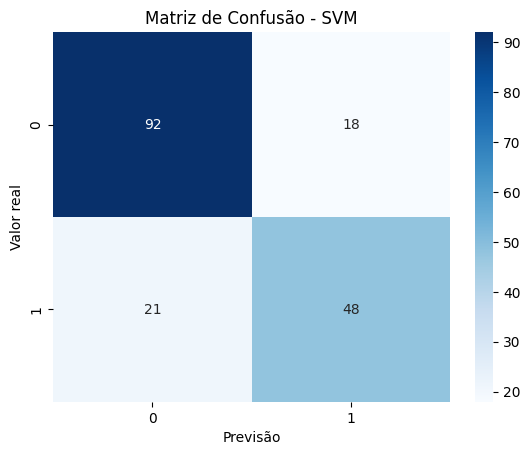

In [31]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Criando a matriz de confusão
cm = confusion_matrix(y_test, y_pred)

# Exibindo a matriz de confusão
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel('Previsão')
plt.ylabel('Valor real')
plt.title('Matriz de Confusão - SVM')
plt.show()

## CONCLUSÃO DO MODELO SVM

Após o treinamento e a otimização realizada pelo GridSearchCV, o melhor modelo encontrado utilizou os parâmetros C = 100, gamma = scale e kernel = rbf.

Na validação cruzada, o modelo apresentou uma acurácia aproximada de 79,92%. Ao realizar o teste com os dados que não foram utilizados durante o treinamento, o modelo apresentou uma acurácia de 78%.

A matriz de confusão mostrou que o modelo conseguiu realizar corretamente a classificação de parte dos passageiros que sobreviveram e dos que não sobreviveram. Dessa forma, o SVM apresentou um desempenho de aproximadamente 78% de acertos no conjunto de teste.